# Q2: Unsupervised Learning - Customer Segmentation

This notebook performs customer segmentation using K-Means clustering and visualises the results using PCA.

Dataset: `q2_customers.csv`

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [7]:
df = pd.read_csv("C:/Users/msoni/Downloads/q2_customers.csv")

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [8]:
print("Dataset shape:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe())

Dataset shape:
(500, 6)

Data types:
age                         int64
annual_spend                int64
visits_per_month            int64
basket_size                 int64
days_since_last_visit       int64
num_categories_purchased    int64
dtype: object

Missing values:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64

Summary statistics:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,40.45200,48856.948000,8.414000,2682.286000,49.466000,4.658000
std,14.42664,32856.795353,5.324595,2274.957339,49.699143,2.438222
min,18.00000,5038.000000,1.000000,212.000000,0.000000,1.000000
25%,28.00000,19213.250000,4.000000,727.750000,12.000000,3.000000
50%,41.00000,44257.000000,8.000000,2051.500000,33.000000,4.000000
75%,50.00000,75373.000000,12.000000,4223.750000,61.250000,6.000000
max,69.00000,119757.000000,19.000000,7981.000000,179.000000,9.000000


In [9]:
features = [
    "age",
    "annual_spend",
    "visits_per_month",
    "basket_size",
    "days_since_last_visit",
    "num_categories_purchased"
]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)

X_scaled_df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


## Data Preparation

All features were scaled using StandardScaler before applying K-Means clustering.

Scaling is essential because K-Means uses distance-based calculations. If features are not scaled, variables with larger numerical ranges, such as annual spend, can dominate the clustering process. StandardScaler brings all features to a similar scale with mean 0 and standard deviation 1, allowing each feature to contribute more fairly to the clustering.

In [10]:
wcss = []

k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

wcss_df = pd.DataFrame({
    "K": list(k_values),
    "WCSS": wcss
})

wcss_df

,K,WCSS
0,1,3000.000000
1,2,968.993871
2,3,561.253006
3,4,444.930276
4,5,402.371303
5,6,370.385393
6,7,346.954081
7,8,319.897475
8,9,303.282250
9,10,289.113979


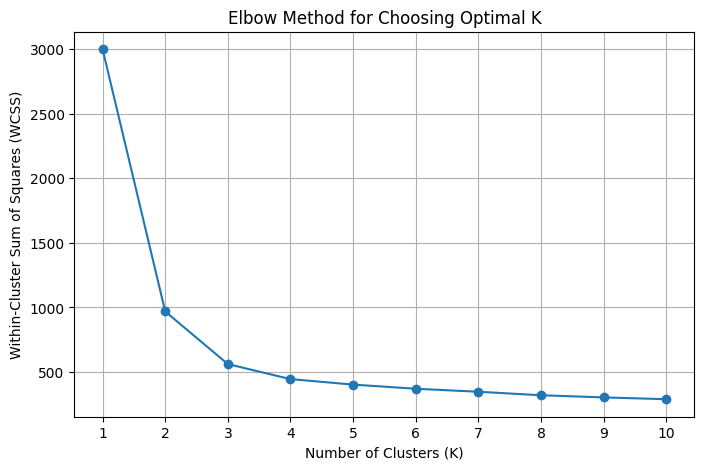

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker="o")
plt.title("Elbow Method for Choosing Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

## Choosing the Optimal K

The elbow method was used to decide the best number of clusters by plotting WCSS for K values from 1 to 10.

From the plot, WCSS drops very sharply from K = 1 to K = 2, and continues to drop noticeably until K = 3. After K = 3, the decrease becomes much smaller and the curve starts flattening.

Therefore, K = 3 is selected as the optimal number of clusters. This gives a good balance between reducing within-cluster variation and keeping the customer segments simple and interpretable.

In [12]:
chosen_k = 3

kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [13]:
cluster_counts = df["cluster"].value_counts().sort_index()

cluster_counts

cluster
0    170
1    165
2    165
Name: count, dtype: int64

In [14]:
centroids_scaled = kmeans.cluster_centers_

centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=features
)

centroids_df.index.name = "cluster"

centroids_df

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
cluster,,,,,,
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


In [15]:
cluster_profile = df.groupby("cluster")[features].mean()

cluster_profile

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
cluster,,,,,,
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


## Cluster Interpretation

Based on the cluster centroids, the customers can be interpreted as follows:

- **Cluster 0: Young frequent low-spenders**  
  This group has the lowest average age, around 25 years. They visit very frequently, with about 14 visits per month, and have the shortest time since last visit. However, their annual spend and basket size are the lowest. This suggests they are active customers but make smaller purchases.

- **Cluster 1: Older high-value inactive customers**  
  This group has the highest average age, around 57 years. They have the highest annual spend, largest basket size, and purchase from the most categories. However, they visit less often and have the highest number of days since last visit. These customers are valuable but may need reactivation campaigns.

- **Cluster 2: Mid-age moderate-value customers**  
  This group has an average age of around 40 years. Their annual spend, basket size, visit frequency, and recency are between Cluster 0 and Cluster 1. They represent a balanced customer segment with moderate engagement and spending.

From a business perspective, Cluster 0 can be targeted with upselling offers, Cluster 1 can be targeted with loyalty and reactivation campaigns, and Cluster 2 can be encouraged to increase purchase frequency and basket size.

In [16]:
pca = PCA(n_components=2, random_state=42)

pca_result = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2"]
)

pca_df["cluster"] = df["cluster"]

pca_df.head()

,PC1,PC2,cluster
0,-0.333082,0.109379,2
1,-2.255362,0.048458,0
2,-0.092905,-0.679257,2
3,-2.017598,-0.308845,0
4,-2.917762,0.529368,0


In [17]:
explained_variance = pd.DataFrame({
    "Principal Component": ["PC1", "PC2"],
    "Explained Variance Ratio": pca.explained_variance_ratio_
})

explained_variance

,Principal Component,Explained Variance Ratio
0,PC1,0.835604
1,PC2,0.055688


In [18]:
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features
)

loadings_df

,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


## PCA Interpretation

PCA was applied to reduce the customer dataset into two principal components for visualisation.

**PC1** is mainly influenced by age, annual spend, basket size, days since last visit, and number of categories purchased in the positive direction, while visits per month has a negative loading. This means PC1 separates customers who are older, spend more, buy larger baskets, purchase across more categories, and have not visited recently from customers who visit more frequently but spend less.

**PC2** is strongly influenced by days since last visit, with a very high positive loading of 0.911994. This means PC2 mainly captures customer recency or inactivity. Customers with higher PC2 values are likely to have a longer time since their last visit.

Overall, PC1 appears to represent customer value and purchase depth, while PC2 mainly represents recency or inactivity.

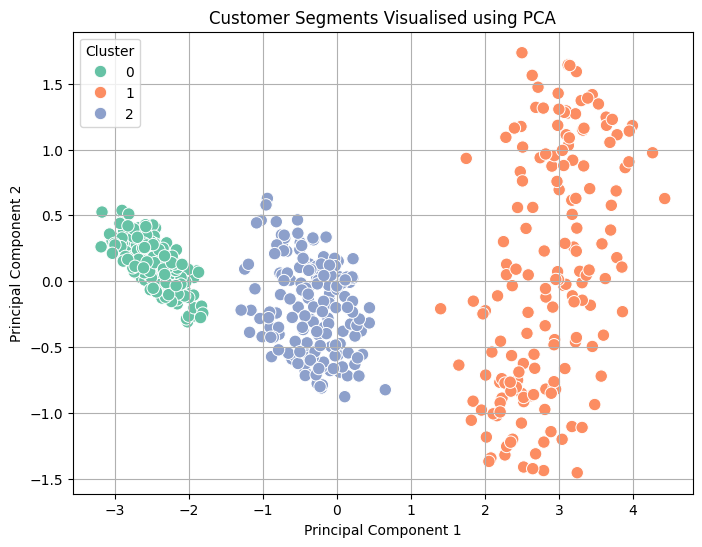

In [19]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2",
    s=80
)

plt.title("Customer Segments Visualised using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

## Final Summary

K-Means clustering was used to segment customers based on their age, annual spend, monthly visits, basket size, days since last visit, and number of categories purchased.

The elbow method suggested using 3 clusters. After fitting K-Means, each customer was assigned a cluster label. The cluster centroids were used to understand the business meaning of each customer segment.

PCA was then applied to reduce the data into two principal components so that the customer segments could be visualised in a 2D scatter plot.